##Segment 1: Upload Packages and Dataset

In [1]:
!pip install pymc arviz -q

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import arviz as az
import matplotlib.pyplot as plt
import urllib.request
import pymc as pm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error




In [2]:
#Upload Dataset
urllib.request.urlretrieve(
    'https://files.grouplens.org/datasets/movielens/ml-100k/u.data',
    'u.data'
)
print("Dataset ready ✓")

Dataset ready ✓


## Segment 2: Baseline Recommender

*   We begin with a simple baseline: predict ratings using global average plus user and item biases.
*   This gives us a strong non-Bayesian benchmark to compare against later.

In [3]:

# Pre-process and build train/test datasets
cols = ['user_id', 'item_id', 'rating', 'timestamp']
df = pd.read_csv('u.data', sep='\t', names=cols)
train, test = train_test_split(df, test_size=0.2, random_state=42)
print(f"Train: {len(train):,} ratings | Test: {len(test):,} ratings")

Train: 80,000 ratings | Test: 20,000 ratings


In [4]:
global_mean = train['rating'].mean()
user_bias = train.groupby('user_id')['rating'].mean() - global_mean
item_bias = train.groupby('item_id')['rating'].mean() - global_mean

def predict(user_id, item_id):
    return (global_mean
            + user_bias.get(user_id, 0)
            + item_bias.get(item_id, 0))

In [5]:
test['pred'] = test.apply(
    lambda r: predict(r.user_id, r.item_id), axis=1
).clip(1, 5)

baseline_rmse = np.sqrt(mean_squared_error(test['rating'], test['pred']))
print(f"Baseline RMSE: {baseline_rmse:.4f}")

Baseline RMSE: 0.9633


In [6]:
# How widespread is sparsity?
rating_counts = train.groupby('user_id').size()
sparse_users = rating_counts[rating_counts <= 20].shape[0]
total_users = rating_counts.shape[0]
print(f"{sparse_users} of {total_users} users have 20 or fewer ratings "
      f"({sparse_users/total_users:.0%})\n")

# The confidence problem
dense_user = rating_counts[rating_counts >= 150].index[0]
sparse_user = rating_counts.idxmin()

print(f"User A: {rating_counts[dense_user]} ratings → pred: {predict(dense_user, 50):.2f}")
print(f"User B: {rating_counts[sparse_user]} ratings  → pred: {predict(sparse_user, 50):.2f}")
print("\nSame output format. But should we trust them equally?")

126 of 943 users have 20 or fewer ratings (13%)

User A: 208 ratings → pred: 4.53
User B: 12 ratings  → pred: 5.51

Same output format. But should we trust them equally?


## Segment 3: Probabilistic Programming Primer  


*   So far, we treated ratings as fixed values.
*   But in reality, we are uncertain about the true average rating.
*   Instead of a single estimate, we can model ratings as random variables and estimate a distribution over possible values.


In [8]:
with pm.Model() as toy_model:
    mu = pm.Normal('mu', mu=3.5, sigma=1.0)
    sigma = pm.HalfNormal('sigma', sigma=1.0)
    ratings = pm.Normal('ratings',
                        mu=mu,
                        sigma=sigma,
                        observed=train['rating'].values[:100])
    trace_toy = pm.sample(
        500,
        tune=200,
        chains=1,
        return_inferencedata=True,
        progressbar=True,
        random_seed=42
    )

Output()

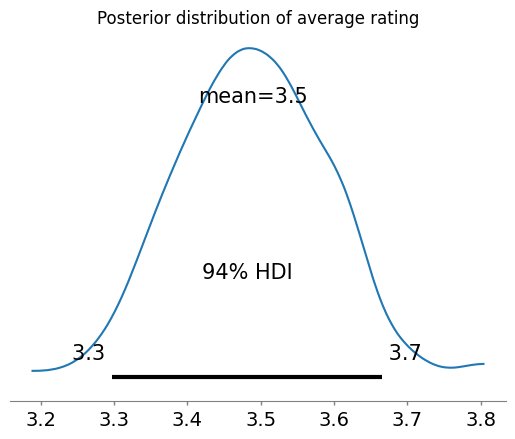

In [9]:
az.plot_posterior(trace_toy, var_names=['mu'])
plt.title("Posterior distribution of average rating")
plt.show()

## Segment 4: Hierarchical Bayesian Model


*   The toy model assumed one global average for all users and items.
*   But real-world data is structured: users and items behave differently.
*  We now extend the model to capture this structure using hierarchical modeling.


In [10]:
rng = np.random.RandomState(42)

sampled_users = rng.choice(
    train['user_id'].unique(),
    size=500,   # adjust up/down depending on speed
    replace=False
)

train_sample = train[train['user_id'].isin(sampled_users)].copy()

# Optional: remove ultra-rare items inside this subsample
item_counts = train_sample['item_id'].value_counts()
train_sample = train_sample[
    train_sample['item_id'].isin(item_counts[item_counts >= 2].index)
].copy()

In [11]:
user_enc2 = LabelEncoder()
item_enc2 = LabelEncoder()

train_sample['user_idx'] = user_enc2.fit_transform(train_sample['user_id'])
train_sample['item_idx'] = item_enc2.fit_transform(train_sample['item_id'])

known_users = set(user_enc2.classes_)
known_items = set(item_enc2.classes_)

test_sample = test[
    test['user_id'].isin(known_users) &
    test['item_id'].isin(known_items)
].copy()

test_sample['user_idx'] = user_enc2.transform(test_sample['user_id'])
test_sample['item_idx'] = item_enc2.transform(test_sample['item_id'])

n_users = train_sample['user_idx'].nunique()
n_items = train_sample['item_idx'].nunique()

In [12]:
print(f"Users: {n_users} | Items: {n_items} | Train: {len(train_sample)} | Test: {len(test_sample)}")
print(f"Rating range: {train_sample['rating'].min()} – {train_sample['rating'].max()}")
print(f"Rating mean:  {train_sample['rating'].mean():.3f}")
print(f"Rating std:   {train_sample['rating'].std():.3f}")
print(f"\nAvg ratings per user: {train_sample.groupby('user_idx').size().mean():.1f}")
print(f"Avg ratings per item: {train_sample.groupby('item_idx').size().mean():.1f}")

Users: 500 | Items: 1429 | Train: 43157 | Test: 10705
Rating range: 1 – 5
Rating mean:  3.517
Rating std:   1.131

Avg ratings per user: 86.3
Avg ratings per item: 30.2


predicted_rating = global_mean + user_offset + item_offset

- global_mean: one number, the overall average
- user_offset: one value per user, how much they rate above/below average
- item_offset: one value per item, how much it gets rated above/below average
- Both offsets use partial pooling — they share a common prior

In [13]:
with pm.Model() as hierarchical_model:
    sigma_user = pm.HalfNormal('sigma_user', sigma=1.0)
    sigma_item = pm.HalfNormal('sigma_item', sigma=1.0)
    global_mean = pm.Normal('global_mean', mu=train_sample['rating'].mean(), sigma=0.5)

    user_offset = pm.Normal('user_offset', mu=0, sigma=sigma_user, shape=n_users)
    item_offset = pm.Normal('item_offset', mu=0, sigma=sigma_item, shape=n_items)

    expected = (
        global_mean
        + user_offset[train_sample['user_idx'].values]
        + item_offset[train_sample['item_idx'].values]
    )

    sigma_obs = pm.HalfNormal('sigma_obs', sigma=1.0)

    rating_obs = pm.Normal(
        'rating_obs',
        mu=expected,
        sigma=sigma_obs,
        observed=train_sample['rating'].values
    )



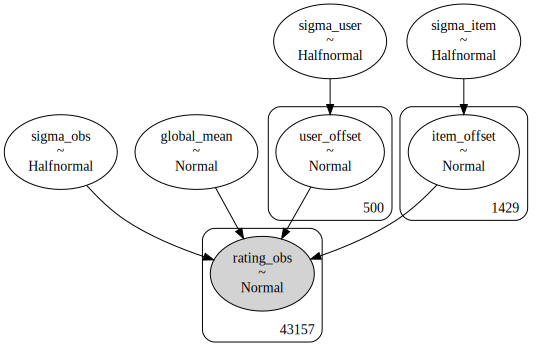

In [14]:
pm.model_to_graphviz(hierarchical_model)

## Segment 5: Evaluation & Comparison


In [15]:
with hierarchical_model:
    trace = pm.sample(
        draws=500,
        tune=300,
        chains=2,
        target_accept=0.9,
        return_inferencedata=True,
        progressbar=True,
        random_seed=42
    )

# Save immediately
trace.to_netcdf('trace_checkpoint.nc')
print("Trace saved ✓")

Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Trace saved ✓


DIAGNOSTICS INTERPRETATION

r_hat (convergence):
*   should be close to 1.00
*   values > 1.01 may indicate convergence issues

ESS (effective sample size):
*   measures how much independent information we have
*   values > 100 are generally acceptable

In our results:
*   Most parameters have r_hat ≈ 1 → good convergence
*   ESS is sufficient for stable estimates

Note:
*   A warning about low ESS for some parameters is
common in hierarchical models,especially with many user/item effects.
*  global_mean shows r_hat of 1.03 and lower ESS.
This is common when the global mean is strongly
correlated with user/item offsets. It does not
invalidate our results — sigma parameters all
converge cleanly.

In [16]:
summary = az.summary(trace, var_names=['global_mean',
                                        'sigma_user',
                                        'sigma_item',
                                        'sigma_obs'])
print(summary)

              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
global_mean  3.346  0.025   3.301    3.396      0.002    0.001     139.0   
sigma_user   0.409  0.014   0.381    0.434      0.000    0.000    2679.0   
sigma_item   0.520  0.013   0.498    0.545      0.000    0.000    1226.0   
sigma_obs    0.927  0.003   0.920    0.932      0.000    0.000    1878.0   

             ess_tail  r_hat  
global_mean     191.0   1.03  
sigma_user      732.0   1.00  
sigma_item      783.0   1.00  
sigma_obs       702.0   1.00  


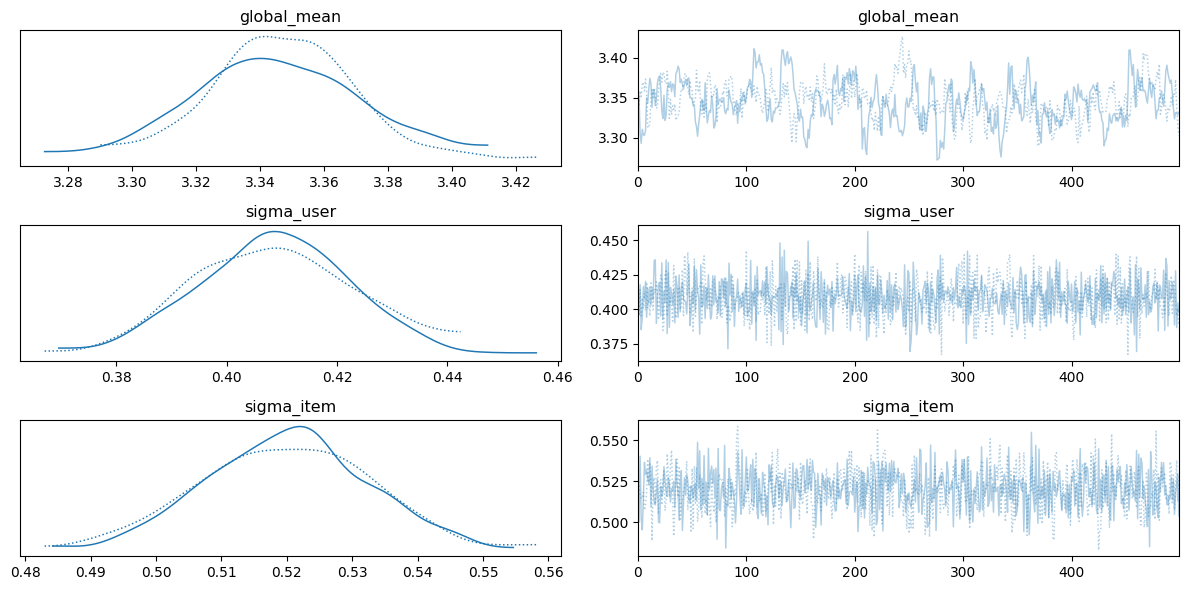

In [17]:
az.plot_trace(trace, var_names=['global_mean',
'sigma_user',
'sigma_item'])
plt.tight_layout()
plt.show()

Trace plot interpretation:

Left plots:
*   posterior distributions of parameters
*   should look smooth and unimodal

Right plots:
*   sampling traces across iterations
*   should look like "fuzzy horizontal bands" (no trends)


If chains mix well and show no drift → sampling is healthy

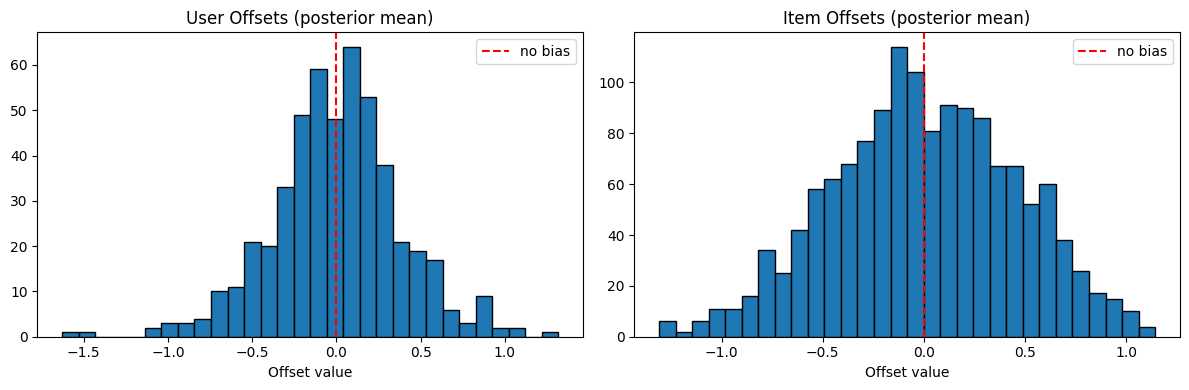

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# User offsets
user_offsets_mean = trace.posterior['user_offset'].mean(
    dim=['chain', 'draw']).values
axes[0].hist(user_offsets_mean, bins=30, edgecolor='black')
axes[0].set_title('User Offsets (posterior mean)')
axes[0].set_xlabel('Offset value')
axes[0].axvline(0, color='red', linestyle='--', label='no bias')
axes[0].legend()

# Item offsets
item_offsets_mean = trace.posterior['item_offset'].mean(
    dim=['chain', 'draw']).values
axes[1].hist(item_offsets_mean, bins=30, edgecolor='black')
axes[1].set_title('Item Offsets (posterior mean)')
axes[1].set_xlabel('Offset value')
axes[1].axvline(0, color='red', linestyle='--', label='no bias')
axes[1].legend()

plt.tight_layout()
plt.show()

In [19]:
user_counts = train_sample['user_id'].value_counts()
item_counts = train_sample['item_id'].value_counts()

print(user_counts.describe())
print(item_counts.describe())

print("Users with 1 rating:", (user_counts == 1).sum())
print("Items with 1 rating:", (item_counts == 1).sum())

count    500.00000
mean      86.31400
std       83.43312
min       12.00000
25%       26.00000
50%       54.00000
75%      112.25000
max      535.00000
Name: count, dtype: float64
count    1429.000000
mean       30.200840
std        35.216213
min         2.000000
25%         6.000000
50%        17.000000
75%        41.000000
max       221.000000
Name: count, dtype: float64
Users with 1 rating: 0
Items with 1 rating: 0


In [20]:


user_offset_samples = trace.posterior['user_offset'].mean(
    dim=['chain', 'draw']).values
item_offset_samples = trace.posterior['item_offset'].mean(
    dim=['chain', 'draw']).values
global_mean_sample = trace.posterior['global_mean'].mean(
    dim=['chain', 'draw']).values

test_sample['pred_bayes'] = (
    global_mean_sample
    + user_offset_samples[test_sample['user_idx'].values]
    + item_offset_samples[test_sample['item_idx'].values]
).clip(1, 5)

pymc_rmse = np.sqrt(mean_squared_error(test_sample['rating'], test_sample['pred_bayes']))
print(f"Baseline RMSE:     {baseline_rmse:.4f}")
print(f"Hierarchical RMSE: {pymc_rmse:.4f}")
print(f"Improvement:       {baseline_rmse - pymc_rmse:.4f}")

Baseline RMSE:     0.9633
Hierarchical RMSE: 0.9457
Improvement:       0.0176


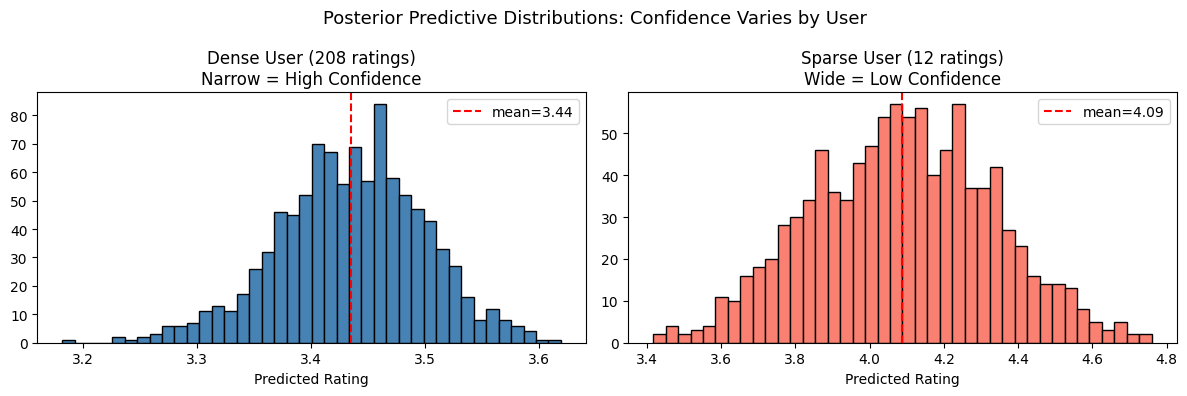

In [21]:
# Uncertainty comparison: dense vs sparse user
dense_uid = rating_counts[rating_counts >= 150].index[0]
sparse_uid = rating_counts.idxmin()

dense_idx = user_enc2.transform([dense_uid])[0]
sparse_idx = user_enc2.transform([sparse_uid])[0] if sparse_uid in known_users else None

# Get full posterior samples for each user's offset
dense_samples = trace.posterior['user_offset'].values[:, :, dense_idx].flatten()
global_samples = trace.posterior['global_mean'].values.flatten()

dense_pred_samples = global_samples + dense_samples

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(dense_pred_samples, bins=40, color='steelblue', edgecolor='black')
axes[0].set_title(f'Dense User ({rating_counts[dense_uid]} ratings)\nNarrow = High Confidence')
axes[0].set_xlabel('Predicted Rating')
axes[0].axvline(dense_pred_samples.mean(), color='red', linestyle='--', label=f'mean={dense_pred_samples.mean():.2f}')
axes[0].legend()

if sparse_idx is not None:
    sparse_samples = trace.posterior['user_offset'].values[:, :, sparse_idx].flatten()
    sparse_pred_samples = global_samples + sparse_samples
    axes[1].hist(sparse_pred_samples, bins=40, color='salmon', edgecolor='black')
    axes[1].set_title(f'Sparse User ({rating_counts[sparse_uid]} ratings)\nWide = Low Confidence')
    axes[1].set_xlabel('Predicted Rating')
    axes[1].axvline(sparse_pred_samples.mean(), color='red', linestyle='--', label=f'mean={sparse_pred_samples.mean():.2f}')
    axes[1].legend()

plt.suptitle('Posterior Predictive Distributions: Confidence Varies by User', fontsize=13)
plt.tight_layout()
plt.show()

 Segment 6: Key Takeaways
 =========================

KEY TAKEAWAYS

1. Baseline models:
   - Treat all users/items equally
   - Do not account for data sparsity

2. Problem:
   - Sparse users (few ratings) produce unreliable estimates
   - Dense users (many ratings) should be trusted more

3. Hierarchical Bayesian solution:
   - Introduces partial pooling
   - Shrinks sparse users toward global average
   - Preserves signal for dense users

4. Model structure:
   rating = global_mean + user_offset + item_offset

5. Why this matters:
   - Reduces overfitting
   - Improves stability
   - Provides uncertainty-aware estimates

6. Key insight:
   Hierarchical models outperform simple baselines
   when there is enough repeated structure in the data.

7. Practical lesson:
   Data structure (not just model complexity)
   is critical for performance.



#Links for Reference and Further Reading


*  [PyMC project website]( https://www.pymc.io/
)
*   [ArviZ documentation ](https://python.arviz.org/en/stable/)
*   [MovieLens 100K ](https://grouplens.org/datasets/movielens/100k/)
*   [Probabilistic Programming & Bayesian Methods for Hackers](https://github.com/CamDavidsonPilon/Probabilistic-Programming-and-Bayesian-Methods-for-Hackers)
*   [Statistical Rethinking](https://github.com/pymc-devs/pymc-resources/tree/main/Rethinking)
*   [Microsoft Recommenders repo](https://github.com/recommenders-team/recommenders)
*   [Recommender Systems and Personalization Datasets](https://cseweb.ucsd.edu/~jmcauley/datasets.html)






